In [15]:
import pandas as pd
import geopandas as gpd
import shapely
from shapely.geometry import Point

# Charger les données
print("Loading data...")
df = pd.read_csv('../../otp-toulouse/toulouse/gtfs/shapes.txt')

# Créer les points (lon, lat)
print("Creating geometries...")
geometry = [Point(xy) for xy in zip(df['shape_pt_lon'], df['shape_pt_lat'])]

# Créer le GeoDataFrame
print("Creating GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Enveloppe convexe globale
print("Calculating convex hull...")
convex_hull = gdf.unary_union.convex_hull

print(f"Shapely version: {shapely.__version__}")
print(f"GEOS version: {shapely.geos_version_string}")

# Enveloppe convexe globale
# concave_hull = gdf.unary_union.concave_hull(ratio=0.1, allow_holes=True)
concave_hull = shapely.concave_hull(gdf.unary_union, ratio=0.1)




Loading data...
Creating geometries...
Creating GeoDataFrame...
Calculating convex hull...
Shapely version: 2.1.2
GEOS version: 3.13.1


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_13378/1438687054.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex_hull = gdf.unary_union.convex_hull
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_13378/1438687054.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  concave_hull = shapely.concave_hull(gdf.unary_union, ratio=0.1)


In [ ]:
tisseo_formdf = gpd.GeoDataFrame(geometry=[convex_hull], crs="EPSG:4326")
# 2. Création du GeoDataFrame pour le point unique (Lon, Lat)
point_geom = Point(1.4531103100078093, 43.63643506805593)
gdf_point = gpd.GeoDataFrame(geometry=[point_geom], crs="EPSG:4326")

m = tisseo_formdf.explore(
    tiles="CartoDB positron",
    zoom_start=12
)

m.save("map.html")
m


In [29]:
point_geom = Point(1.4865697002475673, 43.54417095878383)

point1_geom = Point(1.5104770,43.5173850)
point2_geom = Point(1.5070799,43.5165553)

tisseo_formdf_concave = gpd.GeoDataFrame(geometry=[concave_hull], crs="EPSG:4326")
gdf_point = gpd.GeoDataFrame(geometry=[point_geom], crs="EPSG:4326")
gdf_point1 = gpd.GeoDataFrame(geometry=[point1_geom], crs="EPSG:4326")
gdf_point2 = gpd.GeoDataFrame(geometry=[point2_geom], crs="EPSG:4326")

# Ajout d'une colonne pour différencier les styles
tisseo_formdf_concave['type'] = 'enveloppe'
gdf_point['type'] = 'point'
gdf_point1['type'] = 'point1'
gdf_point2['type'] = 'point2'


combined = gpd.GeoDataFrame(
    pd.concat([tisseo_formdf_concave, gdf_point1, gdf_point2], ignore_index=True),
    crs="EPSG:4326"
)


m = combined.explore(
    column='type',
    tiles="CartoDB positron",
    cmap=['blue', 'yellow'],
    zoom_start=12
)
  

m.save("map_concave.html")





# # Utilisation d'un dictionnaire de correspondance pour les couleurs
# m = combined.explore(
#     column='type',
#     cmap={'enveloppe': 'blue', 'point': 'yellow'},
#     tiles="CartoDB positron",
#     zoom_start=12,
#     marker_kwds=dict(radius=8, fill=True)
# )

# m.save("map_concave.html")
m

In [3]:
pd.set_option('display.max_colwidth', None)
tisseo_formdf



,geometry
0,"POLYGON ((1.26151 43.39634, 1.26147 43.39634, 1.26143 43.39635, 1.26139 43.39637, 1.26136 43.3964, 1.16202 43.5149, 1.15058 43.63709, 1.19749 43.66914, 1.37047 43.75008, 1.37058 43.7501, 1.37276 43.75021, 1.37286 43.7502, 1.48177 43.71813, 1.48186 43.71809, 1.48195 43.71804, 1.51615 43.69548, 1.54378 43.67693, 1.54384 43.67688, 1.54489 43.67575, 1.60548 43.60123, 1.69112 43.48015, 1.68933 43.47678, 1.68692 43.47247, 1.68684 43.47233, 1.68673 43.47217, 1.68662 43.47203, 1.68642 43.47179, 1.6862 43.47154, 1.68546 43.47072, 1.68521 43.47045, 1.59952 43.43614, 1.59947 43.43613, 1.59941 43.43612, 1.2952 43.39725, 1.26151 43.39634))"


In [4]:
import json

with open('../../experiments/current/population_418_418.json') as f:
    data = json.load(f)

coords = []
for person in data:
    identity = person.get("identity", {})
    
    # 🏠 Home
    home = identity.get("home")
    if home:
        coords.append((home["lon"], home["lat"]))
    
    # 📍 Activities
    activities = identity.get("activities", [])
    for act in activities:
        loc = act.get("location")
        if loc:
            coords.append((loc["lon"], loc["lat"]))

coords_gdf = gpd.GeoDataFrame(geometry=[Point(lon, lat) for lon, lat in coords], crs="EPSG:4326")

FileNotFoundError: [Errno 2] No such file or directory: '../../experiments/current/population_418_418.json'

In [5]:
pop_form = coords_gdf.unary_union.convex_hull

NameError: name 'coords_gdf' is not defined

In [6]:

pop_formdf = gpd.GeoDataFrame(geometry=[pop_form], crs="EPSG:4326")

p = pop_formdf.explore(
    tiles="CartoDB positron",
    zoom_start=12
)

p.save("population.html")
p

NameError: name 'pop_form' is not defined

In [7]:
import osmnx as ox
G = ox.graph_from_address("Toulouse, France", dist=15000, network_type="drive")
gdf_edges_15000 = ox.graph_to_gdfs(G, nodes=False, edges=True)
pop_ox_15000 = gdf_edges_15000.unary_union.convex_hull
pop_formox_15000 = gpd.GeoDataFrame(geometry=[pop_ox_15000], crs="EPSG:4326")
pop_formox_15000['source'] = 'Routes OSM (15km)'


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_13378/390215721.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pop_ox_15000 = gdf_edges_15000.unary_union.convex_hull


In [ ]:
import osmnx as ox
G = ox.graph_from_address("Toulouse, France", dist=20000, network_type="drive")
gdf_edges_20000 = ox.graph_to_gdfs(G, nodes=False, edges=True)
pop_ox_20000 = gdf_edges_20000.unary_union.convex_hull
pop_formox_20000 = gpd.GeoDataFrame(geometry=[pop_ox_20000], crs="EPSG:4326")
pop_formox_20000['source'] = 'Routes OSM (20km)'


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_28335/151496964.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pop_ox_20000 = gdf_edges_20000.unary_union.convex_hull


In [8]:
import osmnx as ox
G = ox.graph_from_address("Toulouse, France", dist=30000, network_type="drive")
gdf_edges_30000 = ox.graph_to_gdfs(G, nodes=False, edges=True)
pop_ox_30000 = gdf_edges_30000.unary_union.convex_hull
pop_formox_30000 = gpd.GeoDataFrame(geometry=[pop_ox_30000], crs="EPSG:4326")
pop_formox_30000['source'] = 'Routes OSM (30km)'


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_13378/389836276.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pop_ox_30000 = gdf_edges_30000.unary_union.convex_hull


In [9]:
print(pop_ox_30000)

POLYGON ((1.2429766 43.3346714, 1.0742757 43.3347511, 1.0722625 43.3951164, 1.0713106 43.4551151, 1.071789 43.6822362, 1.0733864 43.8443617, 1.079611 43.8649214, 1.0796576 43.8650054, 1.0801269 43.8655813, 1.0888918 43.8730306, 1.1147683 43.8747801, 1.1150102 43.8747822, 1.6502188 43.8787116, 1.7740606 43.8730095, 1.7923129 43.871795, 1.8154617 43.8688356, 1.8165623 43.8638366, 1.8166405 43.8632419, 1.8174128 43.5934896, 1.8167511 43.3715136, 1.8164324 43.3361861, 1.816419 43.3360199, 1.8084644 43.3349998, 1.7805269 43.3346747, 1.2429766 43.3346714))


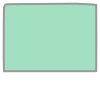

In [10]:
pop_ox_30000

In [ ]:
G = ox.graph_from_address("Toulouse, France", dist=25000, network_type="drive")
gdf_edges_25000 = ox.graph_to_gdfs(G, nodes=False, edges=True)
pop_ox_25000 = gdf_edges_25000.unary_union.convex_hull
pop_formox_25000 = gpd.GeoDataFrame(geometry=[pop_ox_25000], crs="EPSG:4326")
pop_formox_25000['source'] = 'Routes OSM (25km)'

/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_28335/885941550.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pop_ox_25000 = gdf_edges_25000.unary_union.convex_hull


In [ ]:
G = ox.graph_from_address("Toulouse, France", dist=35000, network_type="drive")
gdf_edges_35000 = ox.graph_to_gdfs(G, nodes=False, edges=True)
pop_ox_35000 = gdf_edges_35000.unary_union.convex_hull
pop_formox_35000 = gpd.GeoDataFrame(geometry=[pop_ox_35000], crs="EPSG:4326")
pop_formox_35000['source'] = 'Routes OSM (35km)'

/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_28335/3965498234.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pop_ox_35000 = gdf_edges_35000.unary_union.convex_hull


In [11]:
from shapely.geometry import shape
import geopandas as gpd

def build_shape_gdf(lat_min, lat_max, lon_min, lon_max, name):
    # Création de la boîte englobante
    newbox_data = {
        "type": "Polygon",
        "coordinates": [[[lon_min, lat_min], [lon_max, lat_min], [lon_max, lat_max], [lon_min, lat_max], [lon_min, lat_min]]]
    }
    newbox_gdf = gpd.GeoDataFrame(
        {'source': [name]}, 
        geometry=[shape(newbox_data)], 
        crs="EPSG:4326"
    )

    return newbox_gdf

newbox_gdf2 = build_shape_gdf(lat_min=43.336,lat_max=43.868, lon_min=1.085, lon_max=1.815, name="Equasim")



tisseo_formdf['source'] = 'Tisséo'



combined = gpd.GeoDataFrame(
    #pd.concat([tisseo_formdf, pop_formdf,pop_formox_20000,pop_formox_25000,pop_formox_30000,pop_formox_35000], ignore_index=True),
    pd.concat([tisseo_formdf,pop_formox_30000,newbox_gdf2], ignore_index=True),
    crs="EPSG:4326"
)

c = combined.explore(
    column='source',
    cmap='viridis',               # Palette de couleurs
    tiles="CartoDB positron",
    legend=True,                  # Activé par défaut si 'column' est présent
    zoom_start=12,
    style_kwds={
        "fill": False,       # Supprime le remplissage
        "weight": 2          # Épaisseur du contour (ajustable)
    }
)

c.save("combined.html")
c


In [ ]:


import staticmaps
import render_cairo

# 1. Définition des coordonnées
lat_min, lat_max = 43.336, 43.868
lon_min, lon_max = 1.085, 1.815

# 2. Création de la liste de points (format attendu : List[LatLng])
# Note : py-staticmaps utilise souvent (lat, lon) pour ses propres constructeurs
coordinates = [
    (lat_min, lon_min),
    (lat_min, lon_max),
    (lat_max, lon_max),
    (lat_max, lon_min),
    (lat_min, lon_min)
]

latlngs = [staticmaps.create_latlng(lat, lon) for lat, lon in coordinates]

# 3. Ajout au contexte
context = staticmaps.Context()
context.set_tile_provider(staticmaps.tile_provider_OSM)

context.add_object(
    staticmaps.Area(
        latlngs,
        fill_color=staticmaps.TRANSPARENT,
        color=staticmaps.RED,
        width=2
    )
)

# 4. Rendu
image = context.render_cairo(1200, 800)
image.write_to_png("map_toulouse.png")

ERROR: Could not find a version that satisfies the requirement render_cairo (from versions: none)
ERROR: No matching distribution found for render_cairo


ModuleNotFoundError: No module named 'render_cairo'

0    POLYGON ((1.085 43.336, 1.815 43.336, 1.815 43...
Name: geometry, dtype: geometry


import sys
!{sys.executable} -m pip install contextily

In [ ]:
import sys
!{sys.executable} -m pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 1.5 MB/s  0:00:15 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [contextily]6 [rasterio]


In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

def export_shape_png(gdf, output_name):
    # Passage en projection Web Mercator (EPSG:3857) requis pour les tuiles de fond de carte
    gdf_3857 = gdf.to_crs(epsg=3857)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Affichage de la géométrie (bordure rouge, fond transparent)
    gdf_3857.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
    
    # Ajout du fond de carte (OpenStreetMap par défaut)
    ctx.add_basemap(ax=ax)
    
    # Suppression absolue des bordures, axes et marges
    ax.set_axis_off()
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    plt.margins(0,0)
    
    # Sauvegarde en PNG
    plt.savefig(output_name, bbox_inches='tight', pad_inches=0, dpi=300)
    plt.close()

export_shape_png(newbox_gdf2, "ma_shape.png")

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

def save_clean_map(gdf, output_path, source, dpi=1000):
    # Reprojection pour compatibilité avec les tuiles Web Mercator
    gdf_plot = gdf.to_crs(epsg=3857)
    
    # Création de la figure sans cadres ni marges
    fig = plt.figure(frameon=False, figsize=(12, 12))
    ax = fig.add_axes([0, 0, 1, 1]) # Remplit 100% de la figure
    ax.set_axis_off()

    # Affichage de la shape
    gdf_plot.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1.5)

    # Fond de carte typé (ex: Esri World Imagery pour satellite ou Terrain)
    # Options : ctx.providers.Esri.WorldImagery , ctx.providers.Stamen.Terrain
    ctx.add_basemap(ax=ax, source=source)

    # Forcer les limites strictes de la shape pour éviter les marges
    bounds = gdf_plot.total_bounds
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])

    # Export haute définition
    plt.savefig(output_path, dpi=dpi, bbox_inches=0, pad_inches=0)
    plt.close(fig)

#save_clean_map(newbox_gdf2, "carte_pure_CyclOSM.png",ctx.providers.CyclOSM)
save_clean_map(newbox_gdf2, "carte_pure_Positron.png",ctx.providers.CartoDB.Positron,10000)
save_clean_map(newbox_gdf2, "carte_pure_Esri.WorldGrayCanvas.png",ctx.providers.Esri.WorldGrayCanvas,10000)